# Bank Customer Churn Analysis

## Business context
A retention analyst at a retail bank wants to understand two things: (1) which
customer segments are leaving, and what distinguishes them, and (2) which factors
most strongly predict churn when controlling for the others — so the bank can
target retention effort where it matters.

## Questions
1. Which customer segments are most likely to churn, and what are they doing differently?
2. What factors most strongly predict churn, holding other factors constant?

## Tools
- Python 3.12, pandas, numpy
- matplotlib, seaborn
- statsmodels (logistic regression), scikit-learn (evaluation)

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling (applied once for the whole notebook)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('data/Churn_Modelling.csv')

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (10000, 14)
Columns: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [11]:
df.info()
print("\nTotal nulls:", df.isnull().sum().sum())
print("Duplicate CustomerIds:", df['CustomerId'].duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB

Total nulls: 0
Duplicate CustomerIds: 0


In [12]:
display(df.describe())

churn_rate = df['Exited'].mean()
print(f"\nOverall churn rate: {churn_rate:.1%}")
print(df['Exited'].value_counts())

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000



Overall churn rate: 20.4%
Exited
0    7963
1    2037
Name: count, dtype: int64


## Setting up SQL

The descriptive segmentation below is done in SQL. We load the dataset into an
in-memory SQLite database and query it directly, pulling results into pandas only
to chart them — mirroring how analysis is split in practice: SQL to aggregate,
Python to visualize.

In [13]:
import sqlite3

# In-memory SQLite DB; the connection stays alive for the rest of the notebook
conn = sqlite3.connect(':memory:')
df.to_sql('customers', conn, index=False, if_exists='replace')

# Confirm the table loaded
pd.read_sql_query("SELECT COUNT(*) AS n_rows FROM customers", conn)

,n_rows
0,10000


### Churn by geography

The first segment cut. `AVG(Exited)` is the churn rate — the mean of a 0/1 column
is the proportion of 1s — so it reads as cleanly in SQL as `.mean()` does in pandas.

In [14]:
query = """
SELECT
    Geography,
    COUNT(*)                     AS n_customers,
    SUM(Exited)                  AS n_churned,
    ROUND(AVG(Exited) * 100, 1)  AS churn_rate_pct
FROM customers
GROUP BY Geography
ORDER BY churn_rate_pct DESC
"""
geo_churn = pd.read_sql_query(query, conn)
geo_churn

,Geography,n_customers,n_churned,churn_rate_pct
0,Germany,2509,814,32.4
1,Spain,2477,413,16.7
2,France,5014,810,16.2


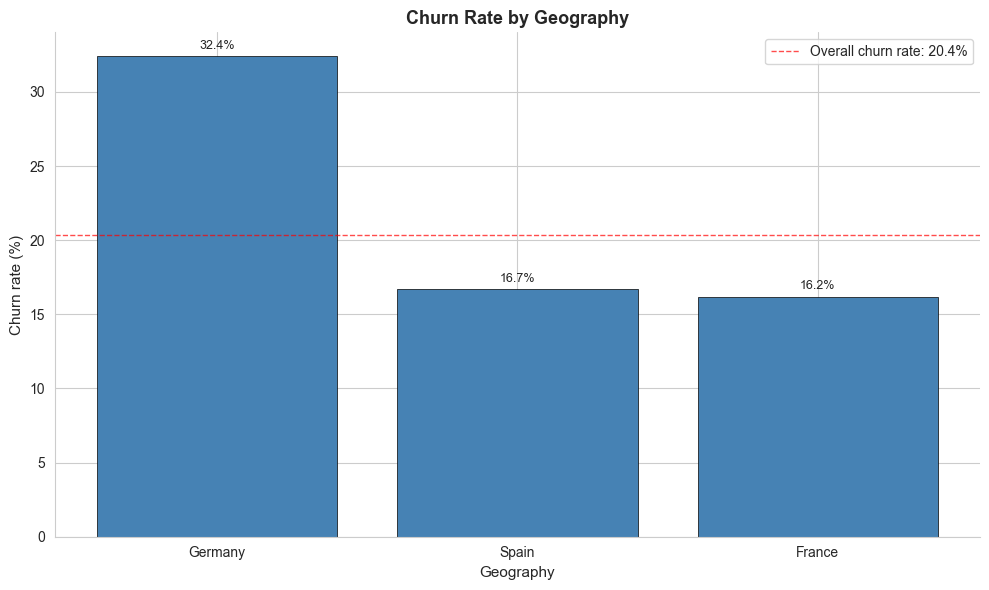

In [15]:
baseline = df['Exited'].mean() * 100

fig, ax = plt.subplots()
bars = ax.bar(geo_churn['Geography'], geo_churn['churn_rate_pct'],
              color='steelblue', edgecolor='black', linewidth=0.5)

ax.axhline(baseline, color='red', linestyle='--', linewidth=1, alpha=0.7,
           label=f'Overall churn rate: {baseline:.1f}%')

ax.set_xlabel('Geography', fontsize=11)
ax.set_ylabel('Churn rate (%)', fontsize=11)
ax.set_title('Churn Rate by Geography', fontsize=13, fontweight='bold')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.3,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()
plt.tight_layout()
plt.show()

**German customers leave at roughly twice the rate of other markets.**

Germany is 25% of the customer base (2,509 of 10,000) but accounts for 40% of all losses. Germany churns at 32.4%, against 16.7% in Spain and 16.2% in France, roughly double either and the only market above the 20.4% baseline.

Each euro spent retaining a German customer prevents more churn than the same euro spread evenly across all three markets.

**Caveat**
Germany's higher churn could partly reflect other things German customers have in common, for instance older age, higher balances, or a different product mix, rather than anything about the country itself. The regression model in `02_modeling.ipynb` will test whether geography predicts churn independently, once those other factors are held constant.

### Churn by age

The second cut. Age is grouped into bands with a SQL CASE expression rather than
queried per individual year, since per-year rates would be noisy and the band view
makes the trend readable. Bucketing a continuous variable with CASE WHEN is a
standard SQL technique for turning a numeric column into interpretable groups.

In [16]:
query = """
SELECT
    CASE
        WHEN Age < 30 THEN '18-29'
        WHEN Age < 40 THEN '30-39'
        WHEN Age < 50 THEN '40-49'
        WHEN Age < 60 THEN '50-59'
        ELSE '60+'
    END                          AS age_band,
    COUNT(*)                     AS n_customers,
    SUM(Exited)                  AS n_churned,
    ROUND(AVG(Exited) * 100, 1)  AS churn_rate_pct
FROM customers
GROUP BY age_band
ORDER BY MIN(Age)
"""
age_churn = pd.read_sql_query(query, conn)
age_churn

,age_band,n_customers,n_churned,churn_rate_pct
0,18-29,1641,124,7.6
1,30-39,4346,473,10.9
2,40-49,2618,806,30.8
3,50-59,869,487,56.0
4,60+,526,147,27.9


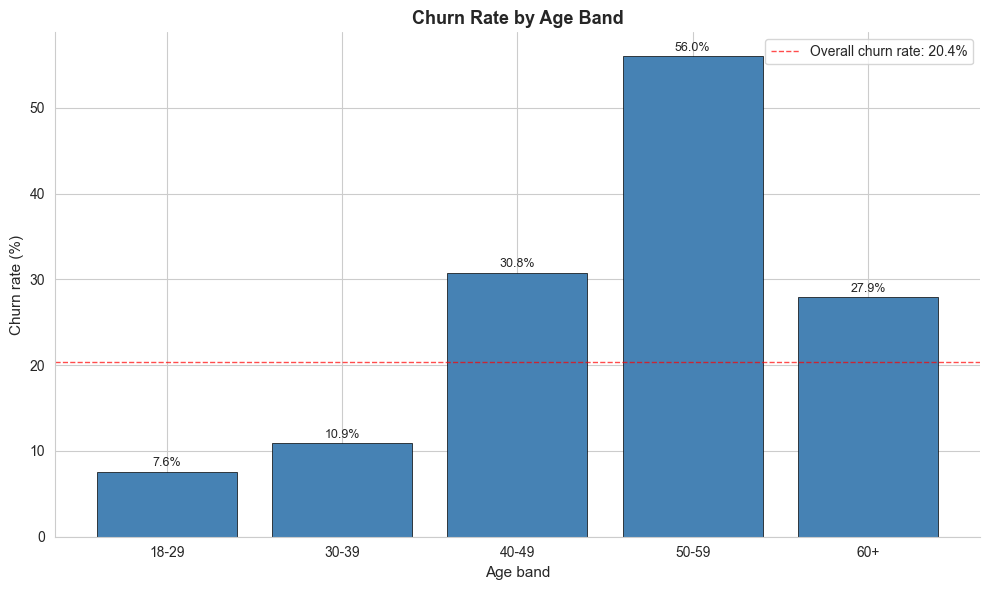

In [17]:
baseline = df['Exited'].mean() * 100

fig, ax = plt.subplots()
bars = ax.bar(age_churn['age_band'], age_churn['churn_rate_pct'],
              color='steelblue', edgecolor='black', linewidth=0.5)

ax.axhline(baseline, color='red', linestyle='--', linewidth=1, alpha=0.7,
           label=f'Overall churn rate: {baseline:.1f}%')

ax.set_xlabel('Age band', fontsize=11)
ax.set_ylabel('Churn rate (%)', fontsize=11)
ax.set_title('Churn Rate by Age Band', fontsize=13, fontweight='bold')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.3,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()
plt.tight_layout()
plt.show()

**Churn rises steeply with age to a peak in the fifties, then eases.**

Churn climbs steeply with age, from 7.6% in the under-thirties to a 56% peak in the fifties, then falls back at 60+. The 50-59 band has the highest rate but only 487 churners, because the band is small. The 40-49 band has a lower rate yet produces 806 churners, the most of any band, because it is far larger. Together these two cohorts are about a third of all customers but produce roughly two-thirds of all churn.

Retention effort should prioritize the 40-49 band first, since it combines a high rate with the largest volume and so reaches the most at-risk customers, followed by 50-59 for the severity of its rate.

**Caveat**

The 60+ band lumps everyone from 60 to 92 into one group and holds a small share of customers, so the drop is best read as churn levelling off rather than a precise estimate.